In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
from pathlib import Path

In [120]:
def plot_percent_change_histogram(df_or_list, title='Distribution of Percent Change Between Replication and Paper Results',
                                   save_path=None, show_counts=False):
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(10, 6))

    if isinstance(df_or_list, list):
        all_percent_changes = []
        for df in df_or_list:
            if 'percent_change' in df.columns:
                all_percent_changes.extend(df['percent_change'].dropna().tolist())
            elif 'percent_difference' in df.columns:
                all_percent_changes.extend(df['percent_difference'].dropna().tolist())
        data = pd.Series(all_percent_changes)
    else:
        col = 'percent_change' if 'percent_change' in df_or_list.columns else 'percent_difference'
        data = df_or_list[col]

    counts, bin_edges, patches = ax.hist(data, edgecolor='black', alpha=0.7)

    if show_counts:
        for count, patch in zip(counts, patches):
            if count > 0:
                height = patch.get_height()
                ax.text(patch.get_x() + patch.get_width()/2., height,
                       f'{int(count)}',
                       ha='center', va='bottom', fontsize=9)

    ax.axvline(data.mean(), color='red', linestyle='--',
               label=f'Mean: {data.mean():.2f}')
    ax.axvline(data.median(), color='green', linestyle='--',
               label=f'Median: {data.median():.2f}')
    ax.set_xlabel('Percent Change')
    ax.set_ylabel('Frequency')
    ax.set_title(title)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, facecolor='white')

    plt.show()

## RocksDB

In [105]:
# Throughput

n_rand_read = """
cores, mode, slowdown
1, kernel_rr, 1.09
2, kernel_rr, 1.26
4, kernel_rr, 1.37
8, kernel_rr, 1.78
16, kernel_rr, 1.90
32, kernel_rr, 2.29
1, whole_system_rr, 1.15
2, whole_system_rr, 3.14
4, whole_system_rr, 5.25
8, whole_system_rr, 8.97
16, whole_system_rr, 27.69
32, whole_system_rr, 33.11"""

n_seq_read = """
cores, mode, slowdown,
1, kernel_rr, 1.34
2, kernel_rr, 1.67
4, kernel_rr, 2.03
8, kernel_rr, 2.79
16, kernel_rr, 4.11
32, kernel_rr, 6.90
1, whole_system_rr, 1.27
2, whole_system_rr, 4.93
4, whole_system_rr, 11.76
8, whole_system_rr, 29.94
16, whole_system_rr, 97.07
32, whole_system_rr, 759.08"""

n_rand_read_one_write = """
cores, mode, slowdown
1, kernel_rr, 1.10
2, kernel_rr, 1.01
4, kernel_rr, 1.06
8, kernel_rr, 1.52
16, kernel_rr, 3.19
32, kernel_rr, 6.91
1, whole_system_rr, 1.08
2, whole_system_rr, 2.96
4, whole_system_rr, 5.88
8, whole_system_rr, 12.29
16, whole_system_rr, 24.92
32, whole_system_rr, 53.66"""

n_rand_read_one_scan = """
cores, mode, slowdown
1, kernel_rr, 1.12
2, kernel_rr, 1.07
4, kernel_rr, 1.38
8, kernel_rr, 1.80
16, kernel_rr, 1.90
32, kernel_rr, 2.25
1, whole_system_rr, 1.11
2, whole_system_rr, 2.71
4, whole_system_rr, 5.08
8, whole_system_rr, 9.49
16, whole_system_rr, 28.11
32, whole_system_rr, 34.70"""

n_rand_seeker = """
cores, mode, slowdown
1, kernel_rr, 1.08
2, kernel_rr, 1.18
4, kernel_rr, 1.35
8, kernel_rr, 2.03
16, kernel_rr, 2.42
32, kernel_rr, 2.77
1, whole_system_rr, 1.12
2, whole_system_rr, 2.92
4, whole_system_rr, 5.58
8, whole_system_rr, 10.24
16, whole_system_rr, 29.70
32, whole_system_rr, 48.16"""

rep_rand_read = """
cores, mode, slowdown
1, kernel_rr, 1.07
2, kernel_rr, 1.16
4, kernel_rr, 1.47
8, kernel_rr, 1.89
16, kernel_rr, 1.88
32, kernel_rr, 2.23
1, whole_system_rr, 1.12
2, whole_system_rr, 2.86
4, whole_system_rr, 5.38
8, whole_system_rr, 9.21
16, whole_system_rr, 26.13
32, whole_system_rr, 34.29"""

rep_seq_read = """
cores, mode, slowdown
1, kernel_rr, 1.14
2, kernel_rr, 1.42
4, kernel_rr, 1.94
8, kernel_rr, 3.02
16, kernel_rr, 3.95
32, kernel_rr, 6.66
1, whole_system_rr, 1.16
2, whole_system_rr, 4.86
4, whole_system_rr, 11.73
8, whole_system_rr, 33.64
16, whole_system_rr, 97.17
32, whole_system_rr, 732.14
"""

rep_rand_seeker = """
cores, mode, slowdown
1, kernel_rr, 1.05
2, kernel_rr, 1.15
4, kernel_rr, 1.38
8, kernel_rr, 2.08
16, kernel_rr, 2.50
32, kernel_rr, 2.69
1, whole_system_rr, 1.08
2, whole_system_rr, 2.83
4, whole_system_rr, 5.86
8, whole_system_rr, 10.17
16, whole_system_rr, 27.70
32, whole_system_rr, 48.45
"""


In [106]:
def calculate_slowdown(csv, modes = ['kernel_rr', 'whole_system_rr']):
    my_results = pd.read_csv(csv)
    my_results.drop("trial", inplace=True, axis = 1)
    baseline = my_results[my_results['mode'] == 'baseline'].set_index('cores')['value']
    results = []
    for mode in modes:
        mode_data = my_results[my_results['mode'] == mode].copy()
        mode_data['slowdown'] = mode_data.apply(
            lambda row: row['value'] / baseline[row['cores']], axis=1
        )
        results.append(mode_data[['cores', 'mode', 'value', 'slowdown']])
    slowdown_df = pd.concat(results, ignore_index=True)
    return slowdown_df

In [107]:
def calculate_percent_change(paper_results, replication_results, value_col: str):
    if isinstance(paper_results, str):
        paper_df = pd.read_csv(io.StringIO(
            paper_results.strip()), skipinitialspace=True)
    else:
        paper_df = paper_results

    if isinstance(replication_results, str):
        rep_df = pd.read_csv(io.StringIO(
            replication_results.strip()), skipinitialspace=True)
    else:
        rep_df = replication_results

    try:
        percent_change_df = paper_df.copy()
        percent_change_df[f"replication_{value_col}"] = rep_df[value_col]
        percent_change_df["percent_change"] = ((percent_change_df[f"replication_{value_col}"]
                                               - percent_change_df[value_col])
                                               / percent_change_df[value_col])
        return percent_change_df
    except:
        return None
    pass

In [110]:
rand_read_change = calculate_percent_change(n_rand_read, rep_rand_read, "slowdown")
seq_read_change = calculate_percent_change(n_seq_read, rep_seq_read, "slowdown")
read_while_write_change = calculate_percent_change(
    n_rand_read_one_write,
    calculate_slowdown("rocksdb_throughput/rocksdb-readwhilewriting-latency.csv"),
    "slowdown"
)
read_while_scan_change = calculate_percent_change(
    n_rand_read_one_scan, calculate_slowdown(
        "rocksdb_throughput/rocksdb-readwhilescanning-latency.csv"),
    "slowdown")
rand_seeker_change = calculate_percent_change(n_rand_seeker, rep_rand_seeker, "slowdown")

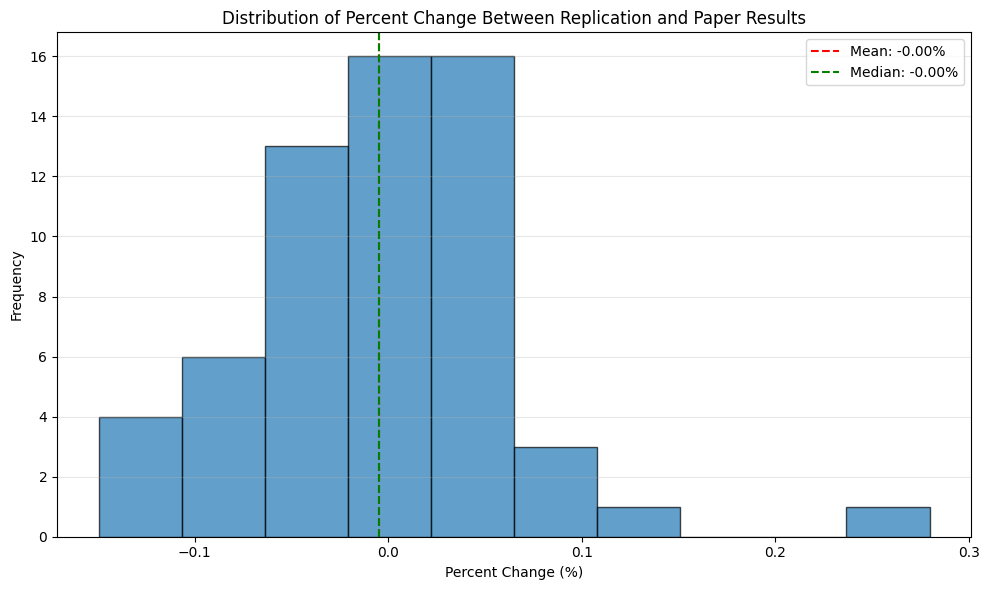

In [111]:
frankenstein = pd.concat([rand_read_change, seq_read_change,
                          read_while_write_change, read_while_scan_change,
                          rand_seeker_change], ignore_index=True)
plot_percent_change_histogram(frankenstein)

## Kernel Build

In [7]:
my_results = pd.read_csv("kernel_build/kernel_build-kernel_build-time.csv")
my_results.drop("trial", inplace=True, axis = 1)
my_results

,cores,mode,value
0,1,baseline,1616.789
1,2,baseline,845.913
2,4,baseline,446.491
3,8,baseline,248.667
4,16,baseline,150.382
5,32,baseline,98.678
6,1,kernel_rr,1875.859
7,2,kernel_rr,1041.084
8,4,kernel_rr,573.586
9,8,kernel_rr,392.735


In [10]:
baseline = my_results[my_results['mode'] == 'baseline'].set_index('cores')['value']

cores
1     1616.789
2      845.913
4      446.491
8      248.667
16     150.382
32      98.678
Name: value, dtype: float64

In [12]:
results = []
for mode in ['kernel_rr', 'whole_system_rr']:
    mode_data = my_results[my_results['mode'] == mode].copy()
    mode_data['slowdown'] = mode_data.apply(
        lambda row: row['value'] / baseline[row['cores']], axis=1
    )
    results.append(mode_data[['cores', 'mode', 'value', 'slowdown']])

slowdown_df = pd.concat(results, ignore_index=True)
slowdown_df

,cores,mode,value,slowdown
0,1,kernel_rr,1875.859,1.160237
1,2,kernel_rr,1041.084,1.230722
2,4,kernel_rr,573.586,1.284653
3,8,kernel_rr,392.735,1.579361
4,16,kernel_rr,552.983,3.677189
5,32,kernel_rr,915.837,9.281066
6,1,whole_system_rr,1807.693,1.118076
7,2,whole_system_rr,2771.263,3.276061
8,4,whole_system_rr,2790.494,6.249833
9,8,whole_system_rr,2960.284,11.904611


In [16]:
paper_results = """
cores, mode, slowdown
1, kernel_rr, 1.15
2, kernel_rr, 1.22
4, kernel_rr, 1.26
8, kernel_rr, 1.56
16, kernel_rr, 3.56
32, kernel_rr, 8.68
1, whole_system_rr, 1.11
2, whole_system_rr, 3.26
4, whole_system_rr, 6.27
8, whole_system_rr, 11.47
16, whole_system_rr, 20.62
32, whole_system_rr, 37.20
"""

paper_df = pd.read_csv(io.StringIO(paper_results.strip()), skipinitialspace=True)
paper_df

,cores,mode,slowdown
0,1,kernel_rr,1.15
1,2,kernel_rr,1.22
2,4,kernel_rr,1.26
3,8,kernel_rr,1.56
4,16,kernel_rr,3.56
5,32,kernel_rr,8.68
6,1,whole_system_rr,1.11
7,2,whole_system_rr,3.26
8,4,whole_system_rr,6.27
9,8,whole_system_rr,11.47


In [19]:
percent_change = slowdown_df.copy()
percent_change["paper_slowdown"] = paper_df["slowdown"]
percent_change["percent_change"] = ((percent_change["slowdown"].round(2)
                                         - percent_change["paper_slowdown"])
                                        / percent_change["paper_slowdown"])
percent_change

,cores,mode,value,slowdown,paper_slowdown,percent_change
0,1,kernel_rr,1875.859,1.160237,1.15,0.008696
1,2,kernel_rr,1041.084,1.230722,1.22,0.008197
2,4,kernel_rr,573.586,1.284653,1.26,0.015873
3,8,kernel_rr,392.735,1.579361,1.56,0.012821
4,16,kernel_rr,552.983,3.677189,3.56,0.033708
5,32,kernel_rr,915.837,9.281066,8.68,0.069124
6,1,whole_system_rr,1807.693,1.118076,1.11,0.009009
7,2,whole_system_rr,2771.263,3.276061,3.26,0.006135
8,4,whole_system_rr,2790.494,6.249833,6.27,-0.003190
9,8,whole_system_rr,2960.284,11.904611,11.47,0.037489


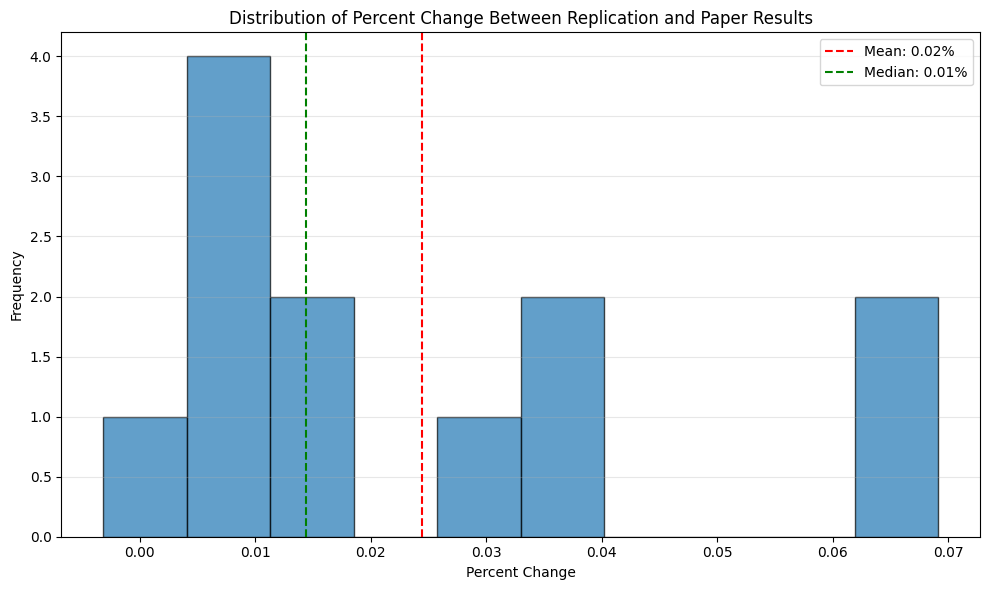

In [75]:
plot_percent_change_histogram(percent_change)

## DPDK

### Redis

In [42]:
rep_get = pd.read_csv("redis_kernel_bypass/redis_dpdk-GET.csv")
rep_set = pd.read_csv("redis_kernel_bypass/redis_dpdk-SET.csv")

In [44]:
paper_get = """
threads, mode, throughput
1, native, 82.21
2, native, 158.70
4, native, 252.15
8, native, 273.94
16, native, 328.66
32, native, 514.86
64, native, 512.10
1, krr, 81.62
2, krr, 158.19
4, krr, 252.58
8, krr, 272.44
16, krr, 328.66
32, krr, 512.61
64, krr, 512.11"""

paper_set = """
threads, mode, throughput
1, native, 81.64
2, native, 157.07
4, native, 251.62
8, native, 272.06
16, native, 310.73
32, native, 491.69
64, native, 489.17
1, krr, 81.47
2, krr, 157.19
4, krr, 250.61
8, krr, 270.22
16, krr, 296.72
32, krr, 487.61
64, krr, 487.15"""

In [45]:
get_change = pd.read_csv(io.StringIO(paper_get.strip()), skipinitialspace=True)
get_change["replication_throughput"] = (rep_get["throughput"]/1000).round(2)
get_change["percent_change"] = ((get_change["replication_throughput"] - get_change["throughput"])
                                / get_change["throughput"])
set_change = pd.read_csv(io.StringIO(paper_set.strip()), skipinitialspace=True)
set_change["replication_throughput"] = (rep_set["throughput"]/1000).round(2)
set_change["percent_change"] = ((set_change["replication_throughput"] - set_change["throughput"])
                                / set_change["throughput"])

In [38]:
get_change

,threads,mode,throughput,replication_throughput,percent_change
0,1,native,82.21,86.44,0.051454
1,2,native,158.70,168.01,0.058664
2,4,native,252.15,281.64,0.116954
3,8,native,273.94,465.03,0.697562
4,15,native,328.66,526.21,0.601077
5,32,native,514.86,512.61,-0.004370
6,64,native,512.10,512.40,0.000586
7,1,krr,81.62,75.77,-0.071674
8,2,krr,158.19,142.82,-0.097162
9,4,krr,252.58,270.23,0.069879


In [46]:
set_change

,threads,mode,throughput,replication_throughput,percent_change
0,1,native,81.64,85.99,0.053283
1,2,native,157.07,166.62,0.060801
2,4,native,251.62,277.73,0.103768
3,8,native,272.06,416.63,0.531390
4,16,native,310.73,512.72,0.650050
5,32,native,491.69,499.80,0.016494
6,64,native,489.17,499.35,0.020811
7,1,krr,81.47,86.44,0.061004
8,2,krr,157.19,166.62,0.059991
9,4,krr,250.61,273.94,0.093093


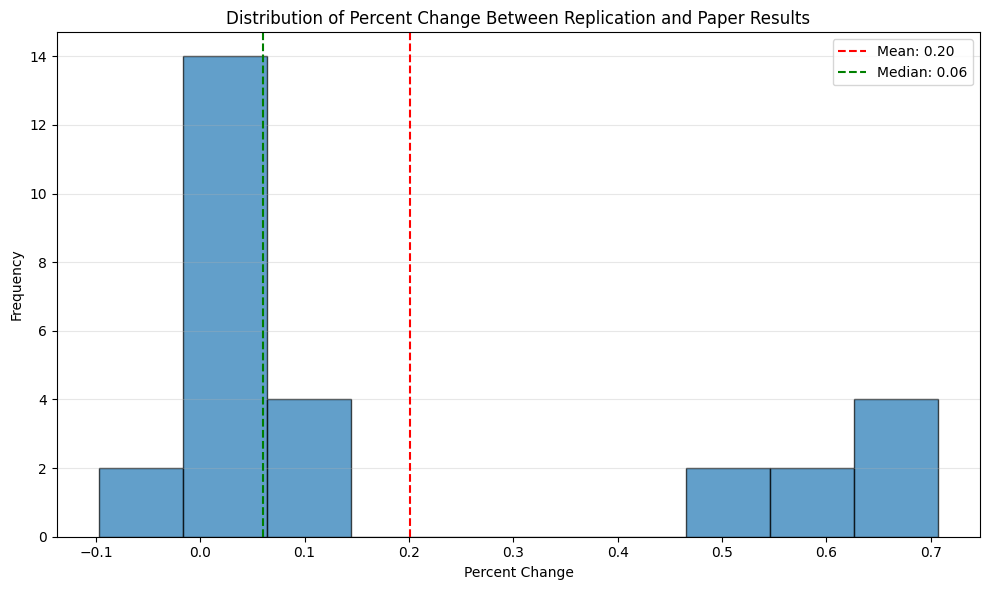

In [122]:
plot_percent_change_histogram(pd.concat([get_change, set_change], ignore_index=True),
                              save_path = "redis.png")

### Nginx

In [48]:
data_dir = Path("nginx_kernel_bypass")
nginx_test_1k = pd.read_csv(data_dir / "nginx-test-1k.csv")
nginx_test_4k = pd.read_csv(data_dir / "nginx-test-4k.csv")
nginx_test_16k = pd.read_csv(data_dir / "nginx-test-16k.csv")
nginx_test_64k = pd.read_csv(data_dir / "nginx-test-64k.csv")

In [50]:
nginx_paper_1k = """
cores, slowdown
1, 1.46
2, 1.55
4, 1.61
8, 2.20
16, 3.73
32, 7.16"""

nginx_paper_4k = """
cores, slowdown
1, 1.38
2, 1.25
4, 1.01
8, 1.01
16, 1.02
32, 2.04
"""

nginx_paper_16k = """
cores, slowdown
1, 1.01
2, 1.01
4, 1.01
8, 1.01
16, 1.01
32, 1.02"""

nginx_paper_64k = """
cores, slowdown
1, 1.01
2, 1.01
4, 1.01
8, 1.02
16, 1.03
32, 1.05"""

In [52]:
nginx_workloads = [
    {"file_size": 1,
     "paper_data": pd.read_csv(io.StringIO(nginx_paper_1k)),
     "replication_data": nginx_test_1k},
    {"file_size": 4,
     "paper_data": pd.read_csv(io.StringIO(nginx_paper_4k)),
     "replication_data": nginx_test_4k},
    {"file_size": 16,
     "paper_data": pd.read_csv(io.StringIO(nginx_paper_16k)),
     "replication_data": nginx_test_16k},
    {"file_size": 64,
     "paper_data": pd.read_csv(io.StringIO(nginx_paper_64k)),
     "replication_data": nginx_test_64k},
]

In [57]:
def calculate_nginx_slowdown(df):
    native = df[df['mode'] == 'native']
    krr = df[df['mode'] == 'krr']

    merged = krr[['cores', 'req/sec']].merge(
        native[['cores', 'req/sec']],
        on='cores',
        suffixes=('_krr', '_native')
    )

    merged['slowdown'] = (merged['req/sec_native']
                          / merged['req/sec_krr']).round(2)

    # Return only cores and slowdown
    return merged[['cores', 'slowdown']]

In [63]:
results = []

for workload in nginx_workloads:
    replication_slowdown = calculate_nginx_slowdown(workload["replication_data"])
    paper_slowdown = workload["paper_data"]
    paper_slowdown.columns = paper_slowdown.columns.str.strip()

    comparison = replication_slowdown.merge(
        paper_slowdown,
        on='cores',
        suffixes=('_replication', '_paper')
    )

    comparison['percent_change'] = (
        (comparison['slowdown_replication'] - comparison['slowdown_paper'])
        / comparison['slowdown_paper']
    )

    comparison['size'] = workload["file_size"]

    results.append(comparison)

final_df = pd.concat(results, ignore_index=True)

final_df = final_df[['size', 'cores', 'slowdown_paper', 'slowdown_replication', 'percent_change']]

final_df

,size,cores,slowdown_paper,slowdown_replication,percent_change
0,1,1,1.46,1.48,0.013699
1,1,2,1.55,1.27,-0.180645
2,1,4,1.61,1.34,-0.167702
3,1,8,2.20,1.80,-0.181818
4,1,16,3.73,3.05,-0.182306
5,1,32,7.16,6.83,-0.046089
6,4,1,1.38,1.39,0.007246
7,4,2,1.25,0.99,-0.208000
8,4,4,1.01,0.80,-0.207921
9,4,8,1.01,0.80,-0.207921


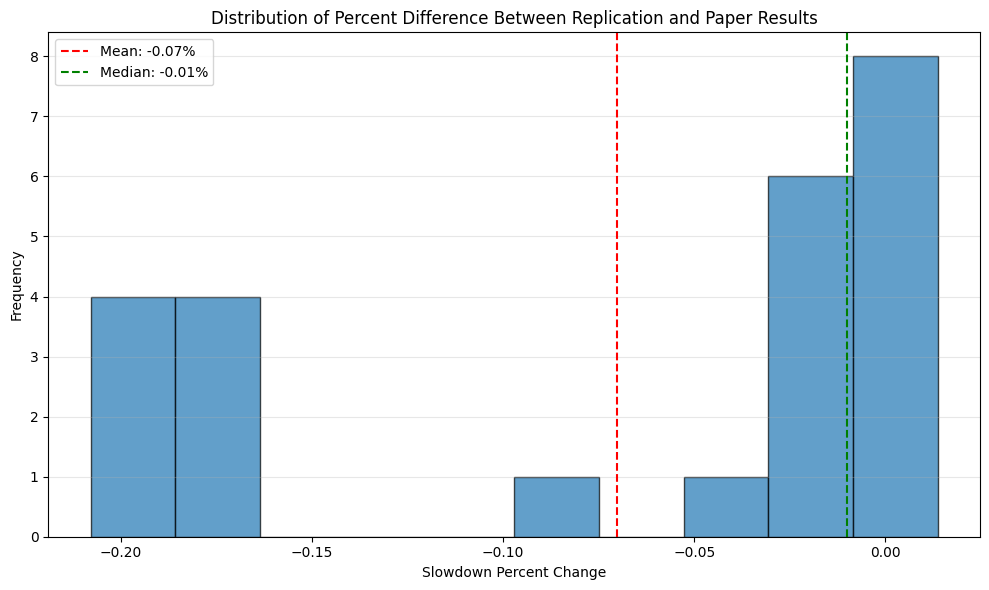

In [68]:
metric = "Slowdown"
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(final_df['percent_change'], edgecolor='black', alpha=0.7)
ax.axvline(final_df['percent_change'].mean(), color='red', linestyle='--',
           label=f'Mean: {final_df["percent_change"].mean():.2f}%')
ax.axvline(final_df['percent_change'].median(), color='green', linestyle='--',
           label=f'Median: {final_df["percent_change"].median():.2f}%')
ax.set_xlabel(f'{metric} Percent Change')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Percent Change Between Replication and Paper Results')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## RocksDB with Kernel Bypass

In [82]:
def calculate_rocksdb_slowdown(df, rocksdb):
    baseline = df[df['mode'] == 'baseline']
    kernel_rr = df[df['mode'] == 'kernel_rr']
    whole_system_rr = df[df['mode'] == 'whole_system_rr']

    results = []

    for mode_name, mode_df in [('kernel_rr', kernel_rr), ('whole_system_rr', whole_system_rr)]:
        merged = mode_df[['cores', 'value']].merge(
            baseline[['cores', 'value']],
            on='cores',
            suffixes=('_mode', '_baseline')
        )

        merged['slowdown'] = merged['value_baseline'] / merged['value_mode']
        merged['mode'] = mode_name

        results.append(merged[['mode', 'cores', 'slowdown']])

    res = pd.concat(results, ignore_index=True)
    res["rocksdb"] = rocksdb
    return res

In [83]:
# Taken from https://github.com/rssys/krr-artifact/blob/main/graph/draw_spdk_rocksdb_graph.py
# lines 12-20
WORKLOAD_DICT = {
    "readseq": "1 sequential reader",
    "seekrandom": "1 random seeker",
    "readrandom": "1 random reader",
    "fillseq" : "1 sequential writer",
    "fillrandom" : "1 random writer",
    "deleteseq": "1 sequential deletion",
    "appendrandom": "1 random appender",
}

In [92]:
paper_readseq = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.41, original
whole_system_rr, 2, 1.83, original
kernel_rr, 2, 1.18, spdk
whole_system_rr, 2, 50.64, spdk"""

paper_readrandom = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.14, original
whole_system_rr, 2, 1.67, original
kernel_rr, 2, 1.17, spdk
whole_system_rr, 2, 35.43, spdk"""

paper_fillseq = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.53, original
whole_system_rr, 2, 2.30, original
kernel_rr, 2, 1.24, spdk
whole_system_rr, 2, 61.31, spdk"""

paper_seekrandom = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.19, original
whole_system_rr, 2, 1.74, original
kernel_rr, 2, 1.18, spdk
whole_system_rr, 2, 42.63, spdk"""

paper_fillrandom = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.54, original
whole_system_rr, 2, 1.95, original
kernel_rr, 2, 1.19, spdk
whole_system_rr, 2, 44.09, spdk"""

paper_deleteseq = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.47, original
whole_system_rr, 2, 1.88, original
kernel_rr, 2, 1.18, spdk
whole_system_rr, 2, 64.51, spdk"""

paper_appendrandom = """
mode, cores, slowdown, rocksdb
kernel_rr, 2, 1.40, original
whole_system_rr, 2, 1.98, original
kernel_rr, 2, 1.26, spdk
whole_system_rr, 2, 29.37, spdk"""


In [94]:
str_dict = {
    "readseq": paper_readseq,
    "readrandom": paper_readrandom,
    "fillseq": paper_fillseq,
    "seekrandom": paper_seekrandom,
    "fillrandom": paper_fillrandom,
    "deleteseq": paper_deleteseq,
    "appendrandom": paper_appendrandom
}

In [100]:
results = []

for k, v in WORKLOAD_DICT.items():
    print(k, v)
    kernel_io_file = f"rocksdb_spdk_study/rocksdb-{k}-opsps.csv"
    spdk_file = f"rocksdb_spdk_study/rocksdb_kernel_bypass-{k}-opsps.csv"
    kernel_io = pd.read_csv(kernel_io_file)
    kernel_io_slowdown = calculate_rocksdb_slowdown(kernel_io, "original")
    spdk = pd.read_csv(spdk_file)
    spdk_slowdown = calculate_rocksdb_slowdown(spdk, "spdk")

    replication_slowdown = pd.concat([kernel_io_slowdown, spdk_slowdown])
    replication_slowdown['mode'] = replication_slowdown['mode'].str.strip()
    replication_slowdown['rocksdb'] = replication_slowdown['rocksdb'].str.strip()
    paper_slowdown = pd.read_csv(io.StringIO(str_dict[k]))
    paper_slowdown.columns = paper_slowdown.columns.str.strip()
    paper_slowdown['mode'] = paper_slowdown['mode'].str.strip()
    paper_slowdown['rocksdb'] = paper_slowdown['rocksdb'].str.strip()
    comparison = replication_slowdown.merge(
        paper_slowdown,
        on=['mode', 'cores', 'rocksdb'],
        suffixes=('_replication', '_paper')
    )

    comparison['percent_change'] = (
        (comparison['slowdown_replication'] - comparison['slowdown_paper'])
        / comparison['slowdown_paper']
    )
    comparison['workload'] = v
    results.append(comparison)

rocksdb_comparison = pd.concat(results, ignore_index=True)
rocksdb_comparison = rocksdb_comparison[['workload', 'rocksdb', 'mode', 'cores', 'slowdown_paper', 'slowdown_replication', 'percent_change']]

rocksdb_comparison

readseq 1 sequential reader
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.291960  original
1  whole_system_rr      2  1.874206  original
seekrandom 1 random seeker
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.121212  original
1  whole_system_rr      2  1.775739  original
readrandom 1 random reader
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.030556  original
1  whole_system_rr      2  1.565600  original
fillseq 1 sequential writer
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.540694  original
1  whole_system_rr      2  2.004053  original
fillrandom 1 random writer
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.476427  original
1  whole_system_rr      2  1.858907  original
deleteseq 1 sequential deletion
              mode  cores  slowdown   rocksdb
0        kernel_rr      2  1.483578  original
1  whole_system_rr      2  2.024142  original
app

,workload,rocksdb,mode,cores,slowdown_paper,slowdown_replication,percent_change
0,1 sequential reader,original,kernel_rr,2,1.41,1.291960,-0.083716
1,1 sequential reader,original,whole_system_rr,2,1.83,1.874206,0.024156
2,1 sequential reader,spdk,kernel_rr,2,1.18,1.319315,0.118063
3,1 sequential reader,spdk,whole_system_rr,2,50.64,50.161778,-0.009444
4,1 random seeker,original,kernel_rr,2,1.19,1.121212,-0.057805
5,1 random seeker,original,whole_system_rr,2,1.74,1.775739,0.020539
6,1 random seeker,spdk,kernel_rr,2,1.18,1.141209,-0.032874
7,1 random seeker,spdk,whole_system_rr,2,42.63,41.961066,-0.015692
8,1 random reader,original,kernel_rr,2,1.14,1.030556,-0.096003
9,1 random reader,original,whole_system_rr,2,1.67,1.565600,-0.062515


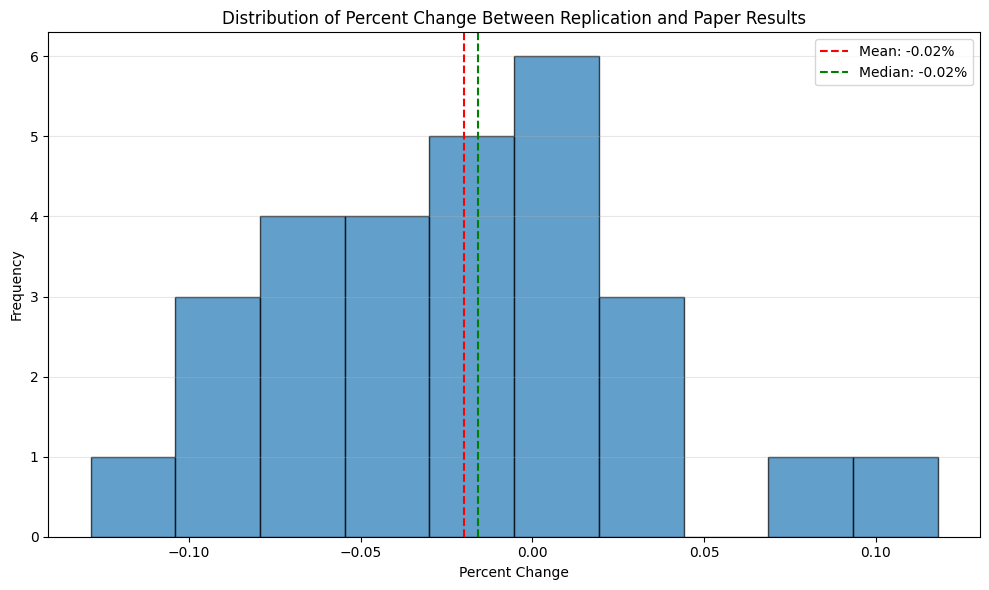

In [101]:
plot_percent_change_histogram(rocksdb_comparison)

## What about a big huge giant histogram??

In [112]:
dfs = [rocksdb_comparison, final_df, pd.concat([get_change, set_change]),
       percent_change, frankenstein]

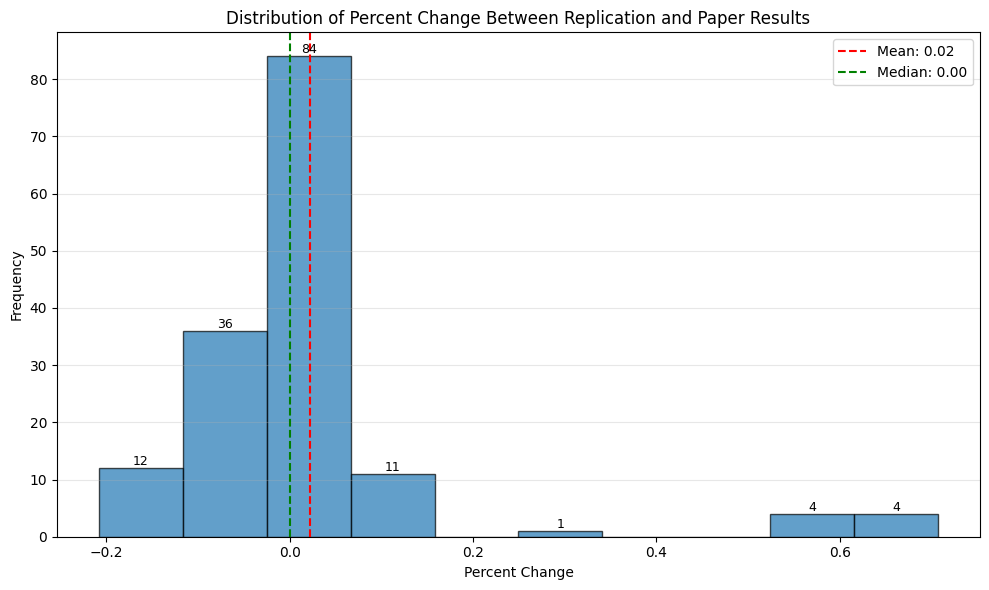

In [118]:
plot_percent_change_histogram(dfs, show_counts = True,
                              save_path = "./all_percent_change_histogram.png")